In [329]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

Convert json files into csv files

In [330]:
with open(r"C:\ML\cricket_team\t20_json_files\t20_wc_match_results.json") as f:
    data = json.load(f)
df_match =pd.DataFrame(data[0]['matchSummary'])
df_match.head(10)

,team1,team2,winner,margin,ground,matchDate,scorecard
0,Namibia,Sri Lanka,Namibia,55 runs,Geelong,"Oct 16, 2022",T20I # 1823
1,Netherlands,U.A.E.,Netherlands,3 wickets,Geelong,"Oct 16, 2022",T20I # 1825
2,Scotland,West Indies,Scotland,42 runs,Hobart,"Oct 17, 2022",T20I # 1826
3,Ireland,Zimbabwe,Zimbabwe,31 runs,Hobart,"Oct 17, 2022",T20I # 1828
4,Namibia,Netherlands,Netherlands,5 wickets,Geelong,"Oct 18, 2022",T20I # 1830
5,Sri Lanka,U.A.E.,Sri Lanka,79 runs,Geelong,"Oct 18, 2022",T20I # 1832
6,Ireland,Scotland,Ireland,6 wickets,Hobart,"Oct 19, 2022",T20I # 1833
7,West Indies,Zimbabwe,West Indies,31 runs,Hobart,"Oct 19, 2022",T20I # 1834
8,Netherlands,Sri Lanka,Sri Lanka,16 runs,Geelong,"Oct 20, 2022",T20I # 1835
9,Namibia,U.A.E.,U.A.E.,7 runs,Geelong,"Oct 20, 2022",T20I # 1836


In [331]:
df_match.shape
df_match.info()


<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   team1      45 non-null     str  
 1   team2      45 non-null     str  
 2   winner     45 non-null     str  
 3   margin     45 non-null     str  
 4   ground     45 non-null     str  
 5   matchDate  45 non-null     str  
 6   scorecard  45 non-null     str  
dtypes: str(7)
memory usage: 5.4 KB


In [332]:
df_match.rename(columns={"scorecard": "match_id"}, inplace=True)
df_match.head()

,team1,team2,winner,margin,ground,matchDate,match_id
0,Namibia,Sri Lanka,Namibia,55 runs,Geelong,"Oct 16, 2022",T20I # 1823
1,Netherlands,U.A.E.,Netherlands,3 wickets,Geelong,"Oct 16, 2022",T20I # 1825
2,Scotland,West Indies,Scotland,42 runs,Hobart,"Oct 17, 2022",T20I # 1826
3,Ireland,Zimbabwe,Zimbabwe,31 runs,Hobart,"Oct 17, 2022",T20I # 1828
4,Namibia,Netherlands,Netherlands,5 wickets,Geelong,"Oct 18, 2022",T20I # 1830


In [333]:
df_match["winner"].value_counts()

winner
England         5
Netherlands     4
Sri Lanka       4
India           4
Pakistan        4
Zimbabwe        3
Ireland         3
New Zealand     3
Australia       3
abandoned       3
Bangladesh      2
South Africa    2
Namibia         1
Scotland        1
West Indies     1
U.A.E.          1
no result       1
Name: count, dtype: int64

In [334]:
df_match.to_csv(r"C:\ML\cricket_team\t20_wc_Csv\t20_wc_match_results.csv", index=False)

Batting Summary

In [335]:
with open(r"C:\ML\cricket_team\t20_json_files\t20_wc_batting_summary.json") as f:
    data = json.load(f)
    all_record =[]
    for rec in data:
        all_record.extend(rec['battingSummary'])
df_batting = pd.DataFrame(all_record)
df_batting.head(11)

,match,teamInnings,battingPos,batsmanName,dismissal,runs,balls,4s,6s,SR
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,c Pramod Madushan b Chameera,3,6,0,0,50.00
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,c Shanaka b Pramod Madushan,9,9,1,0,100.00
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,c †Mendis b Karunaratne,20,12,1,2,166.66
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,c DM de Silva b Pramod Madushan,26,24,2,0,108.33
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),c Gunathilaka b PWH de Silva,20,24,0,0,83.33
5,Namibia Vs Sri Lanka,Namibia,6,Jan Frylinck,run out (Gunathilaka/†Mendis),44,28,4,0,157.14
6,Namibia Vs Sri Lanka,Namibia,7,David Wiese,c †Mendis b Theekshana,0,1,0,0,0.00
7,Namibia Vs Sri Lanka,Namibia,8,JJ Smit,,31,16,2,2,193.75
8,Namibia Vs Sri Lanka,Sri Lanka,1,Pathum Nissanka,c Smit b Shikongo,9,10,1,0,90.00
9,Namibia Vs Sri Lanka,Sri Lanka,2,Kusal Mendis†,c †Green b Wiese,6,6,0,0,100.00


In [336]:
df_batting["out/not out"] = df_batting.dismissal.apply(lambda x: "out" if len(x) > 0 else "not out")
df_batting.head(11)

,match,teamInnings,battingPos,batsmanName,dismissal,runs,balls,4s,6s,SR,out/not out
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,c Pramod Madushan b Chameera,3,6,0,0,50.00,out
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,c Shanaka b Pramod Madushan,9,9,1,0,100.00,out
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,c †Mendis b Karunaratne,20,12,1,2,166.66,out
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,c DM de Silva b Pramod Madushan,26,24,2,0,108.33,out
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),c Gunathilaka b PWH de Silva,20,24,0,0,83.33,out
5,Namibia Vs Sri Lanka,Namibia,6,Jan Frylinck,run out (Gunathilaka/†Mendis),44,28,4,0,157.14,out
6,Namibia Vs Sri Lanka,Namibia,7,David Wiese,c †Mendis b Theekshana,0,1,0,0,0.00,out
7,Namibia Vs Sri Lanka,Namibia,8,JJ Smit,,31,16,2,2,193.75,not out
8,Namibia Vs Sri Lanka,Sri Lanka,1,Pathum Nissanka,c Smit b Shikongo,9,10,1,0,90.00,out
9,Namibia Vs Sri Lanka,Sri Lanka,2,Kusal Mendis†,c †Green b Wiese,6,6,0,0,100.00,out


In [337]:
df_batting.drop(columns = ["dismissal"], inplace = True)
df_batting.head(11)

,match,teamInnings,battingPos,batsmanName,runs,balls,4s,6s,SR,out/not out
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,3,6,0,0,50.00,out
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,9,9,1,0,100.00,out
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,20,12,1,2,166.66,out
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,26,24,2,0,108.33,out
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),20,24,0,0,83.33,out
5,Namibia Vs Sri Lanka,Namibia,6,Jan Frylinck,44,28,4,0,157.14,out
6,Namibia Vs Sri Lanka,Namibia,7,David Wiese,0,1,0,0,0.00,out
7,Namibia Vs Sri Lanka,Namibia,8,JJ Smit,31,16,2,2,193.75,not out
8,Namibia Vs Sri Lanka,Sri Lanka,1,Pathum Nissanka,9,10,1,0,90.00,out
9,Namibia Vs Sri Lanka,Sri Lanka,2,Kusal Mendis†,6,6,0,0,100.00,out


In [338]:
match_ids_dict ={}
for index, row in df_match.iterrows():
    key1=row["team1"] + " Vs " + row["team2"]
    key2=row["team2"] + " Vs " + row["team1"]
    match_ids_dict[key1] = row["match_id"]
    match_ids_dict[key2] = row["match_id"]
match_ids_dict

{'Namibia Vs Sri Lanka': 'T20I # 1823',
 'Sri Lanka Vs Namibia': 'T20I # 1823',
 'Netherlands Vs U.A.E.': 'T20I # 1825',
 'U.A.E. Vs Netherlands': 'T20I # 1825',
 'Scotland Vs West Indies': 'T20I # 1826',
 'West Indies Vs Scotland': 'T20I # 1826',
 'Ireland Vs Zimbabwe': 'T20I # 1828',
 'Zimbabwe Vs Ireland': 'T20I # 1828',
 'Namibia Vs Netherlands': 'T20I # 1830',
 'Netherlands Vs Namibia': 'T20I # 1830',
 'Sri Lanka Vs U.A.E.': 'T20I # 1832',
 'U.A.E. Vs Sri Lanka': 'T20I # 1832',
 'Ireland Vs Scotland': 'T20I # 1833',
 'Scotland Vs Ireland': 'T20I # 1833',
 'West Indies Vs Zimbabwe': 'T20I # 1834',
 'Zimbabwe Vs West Indies': 'T20I # 1834',
 'Netherlands Vs Sri Lanka': 'T20I # 1835',
 'Sri Lanka Vs Netherlands': 'T20I # 1835',
 'Namibia Vs U.A.E.': 'T20I # 1836',
 'U.A.E. Vs Namibia': 'T20I # 1836',
 'Ireland Vs West Indies': 'T20I # 1837',
 'West Indies Vs Ireland': 'T20I # 1837',
 'Scotland Vs Zimbabwe': 'T20I # 1838',
 'Zimbabwe Vs Scotland': 'T20I # 1838',
 'Australia Vs New Zea

Map match summary on batting summary

In [339]:
df_batting["match_id"] =df_batting["match"].map(match_ids_dict)
df_batting.head(11)

,match,teamInnings,battingPos,batsmanName,runs,balls,4s,6s,SR,out/not out,match_id
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,3,6,0,0,50.00,out,T20I # 1823
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,9,9,1,0,100.00,out,T20I # 1823
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,20,12,1,2,166.66,out,T20I # 1823
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,26,24,2,0,108.33,out,T20I # 1823
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),20,24,0,0,83.33,out,T20I # 1823
5,Namibia Vs Sri Lanka,Namibia,6,Jan Frylinck,44,28,4,0,157.14,out,T20I # 1823
6,Namibia Vs Sri Lanka,Namibia,7,David Wiese,0,1,0,0,0.00,out,T20I # 1823
7,Namibia Vs Sri Lanka,Namibia,8,JJ Smit,31,16,2,2,193.75,not out,T20I # 1823
8,Namibia Vs Sri Lanka,Sri Lanka,1,Pathum Nissanka,9,10,1,0,90.00,out,T20I # 1823
9,Namibia Vs Sri Lanka,Sri Lanka,2,Kusal Mendis†,6,6,0,0,100.00,out,T20I # 1823


In [340]:
df_batting.to_csv(r"C:\ML\cricket_team\t20_wc_Csv\t20_wc_batting_summary.csv", index=False)

In [341]:
with open(r"C:\ML\cricket_team\t20_json_files\t20_wc_bowling_summary.json") as f:
    data = json.load(f)
    all_records =[]
    for rec in data:
        all_records.extend(rec["bowlingSummary"])
df_bowling = pd.DataFrame(all_records)
df_bowling.head(11)


,match,bowlingTeam,bowlerName,overs,maiden,runs,wickets,economy,0s,4s,6s,wides,noBalls
0,Namibia Vs Sri Lanka,Sri Lanka,Maheesh Theekshana,4,0,23,1,5.75,7,0,0,2,0
1,Namibia Vs Sri Lanka,Sri Lanka,Dushmantha Chameera,4,0,39,1,9.75,6,3,1,2,0
2,Namibia Vs Sri Lanka,Sri Lanka,Pramod Madushan,4,0,37,2,9.25,6,3,1,0,0
3,Namibia Vs Sri Lanka,Sri Lanka,Chamika Karunaratne,4,0,36,1,9.00,7,3,1,1,0
4,Namibia Vs Sri Lanka,Sri Lanka,Wanindu Hasaranga de Silva,4,0,27,1,6.75,8,1,1,0,0
5,Namibia Vs Sri Lanka,Namibia,Gerhard Erasmus,1,0,8,0,8.00,1,1,0,0,0
6,Namibia Vs Sri Lanka,Namibia,David Wiese,4,0,16,2,4.00,13,1,0,0,0
7,Namibia Vs Sri Lanka,Namibia,Bernard Scholtz,4,0,18,2,4.50,10,1,0,0,0
8,Namibia Vs Sri Lanka,Namibia,Ben Shikongo,3,1,22,2,7.33,6,3,0,0,0
9,Namibia Vs Sri Lanka,Namibia,JJ Smit,3,0,16,1,5.33,7,0,0,1,0


mapping bowling performances to match summary or match ids


In [342]:
match_ids_dict

{'Namibia Vs Sri Lanka': 'T20I # 1823',
 'Sri Lanka Vs Namibia': 'T20I # 1823',
 'Netherlands Vs U.A.E.': 'T20I # 1825',
 'U.A.E. Vs Netherlands': 'T20I # 1825',
 'Scotland Vs West Indies': 'T20I # 1826',
 'West Indies Vs Scotland': 'T20I # 1826',
 'Ireland Vs Zimbabwe': 'T20I # 1828',
 'Zimbabwe Vs Ireland': 'T20I # 1828',
 'Namibia Vs Netherlands': 'T20I # 1830',
 'Netherlands Vs Namibia': 'T20I # 1830',
 'Sri Lanka Vs U.A.E.': 'T20I # 1832',
 'U.A.E. Vs Sri Lanka': 'T20I # 1832',
 'Ireland Vs Scotland': 'T20I # 1833',
 'Scotland Vs Ireland': 'T20I # 1833',
 'West Indies Vs Zimbabwe': 'T20I # 1834',
 'Zimbabwe Vs West Indies': 'T20I # 1834',
 'Netherlands Vs Sri Lanka': 'T20I # 1835',
 'Sri Lanka Vs Netherlands': 'T20I # 1835',
 'Namibia Vs U.A.E.': 'T20I # 1836',
 'U.A.E. Vs Namibia': 'T20I # 1836',
 'Ireland Vs West Indies': 'T20I # 1837',
 'West Indies Vs Ireland': 'T20I # 1837',
 'Scotland Vs Zimbabwe': 'T20I # 1838',
 'Zimbabwe Vs Scotland': 'T20I # 1838',
 'Australia Vs New Zea

In [343]:
df_bowling["match_id"] =df_bowling["match"].map(match_ids_dict)
df_bowling.head(11)

,match,bowlingTeam,bowlerName,overs,maiden,runs,wickets,economy,0s,4s,6s,wides,noBalls,match_id
0,Namibia Vs Sri Lanka,Sri Lanka,Maheesh Theekshana,4,0,23,1,5.75,7,0,0,2,0,T20I # 1823
1,Namibia Vs Sri Lanka,Sri Lanka,Dushmantha Chameera,4,0,39,1,9.75,6,3,1,2,0,T20I # 1823
2,Namibia Vs Sri Lanka,Sri Lanka,Pramod Madushan,4,0,37,2,9.25,6,3,1,0,0,T20I # 1823
3,Namibia Vs Sri Lanka,Sri Lanka,Chamika Karunaratne,4,0,36,1,9.00,7,3,1,1,0,T20I # 1823
4,Namibia Vs Sri Lanka,Sri Lanka,Wanindu Hasaranga de Silva,4,0,27,1,6.75,8,1,1,0,0,T20I # 1823
5,Namibia Vs Sri Lanka,Namibia,Gerhard Erasmus,1,0,8,0,8.00,1,1,0,0,0,T20I # 1823
6,Namibia Vs Sri Lanka,Namibia,David Wiese,4,0,16,2,4.00,13,1,0,0,0,T20I # 1823
7,Namibia Vs Sri Lanka,Namibia,Bernard Scholtz,4,0,18,2,4.50,10,1,0,0,0,T20I # 1823
8,Namibia Vs Sri Lanka,Namibia,Ben Shikongo,3,1,22,2,7.33,6,3,0,0,0,T20I # 1823
9,Namibia Vs Sri Lanka,Namibia,JJ Smit,3,0,16,1,5.33,7,0,0,1,0,T20I # 1823


In [344]:
df_bowling.to_csv(r"C:\ML\cricket_team\t20_wc_Csv\t20_wc_bowling_summary.csv", index=False)

In [345]:
df_powerhitters=pd.read_csv(r"C:\ML\cricket_team\t20_wc_Csv\t20_wc_batting_summary.csv")
df_powerhitters.head()

,match,teamInnings,battingPos,batsmanName,runs,balls,4s,6s,SR,out/not out,match_id
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,3,6,0,0,50.00,out,T20I # 1823
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,9,9,1,0,100.00,out,T20I # 1823
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,20,12,1,2,166.66,out,T20I # 1823
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,26,24,2,0,108.33,out,T20I # 1823
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),20,24,0,0,83.33,out,T20I # 1823


In [346]:
df_powerhitters["SR"]=pd.to_numeric(df_powerhitters["SR"],errors ="coerce")
df_powerhitters=df_powerhitters[df_powerhitters["SR"]>160]
df_powerhitters.head()




,match,teamInnings,battingPos,batsmanName,runs,balls,4s,6s,SR,out/not out,match_id
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,20,12,1,2,166.66,out,T20I # 1823
7,Namibia Vs Sri Lanka,Namibia,8,JJ Smit,31,16,2,2,193.75,not out,T20I # 1823
42,Scotland Vs West Indies,Scotland,5,Calum MacLeod,23,14,4,0,164.28,out,T20I # 1826
60,Zimbabwe Vs Ireland,Zimbabwe,5,Sikandar Raza,82,48,5,5,170.83,out,T20I # 1828
63,Zimbabwe Vs Ireland,Zimbabwe,8,Luke Jongwe,20,10,3,0,200.00,not out,T20I # 1828


In [347]:
df_powerhitters["batsmanName"].value_counts()

batsmanName
Sikandar Raza       4
Suryakumar Yadav    4
Glenn Phillips      3
Curtis Campher      2
Finn Allen          2
                   ..
Anrich Nortje       1
Shan Masood         1
Hardik Pandya       1
Jos Buttler(c)†     1
Alex Hales          1
Name: count, Length: 61, dtype: int64

In [348]:
df_powerhitters["runs"]=pd.to_numeric(df_powerhitters["runs"],errors="coerce")
df_powerhitters["balls"]=pd.to_numeric(df_powerhitters["balls"],errors="coerce")
df_powerhitters["4s"]=pd.to_numeric(df_powerhitters["4s"],errors="coerce")
df_powerhitters["6s"]=pd.to_numeric(df_powerhitters["6s"],errors="coerce")

In [349]:
df_powerhitters=df_powerhitters[df_powerhitters["runs"]>20]
df_powerhitters.head()


,match,teamInnings,battingPos,batsmanName,runs,balls,4s,6s,SR,out/not out,match_id
7,Namibia Vs Sri Lanka,Namibia,8,JJ Smit,31,16,2,2,193.75,not out,T20I # 1823
42,Scotland Vs West Indies,Scotland,5,Calum MacLeod,23,14,4,0,164.28,out,T20I # 1826
60,Zimbabwe Vs Ireland,Zimbabwe,5,Sikandar Raza,82,48,5,5,170.83,out,T20I # 1828
121,Scotland Vs Ireland,Ireland,5,Curtis Campher,72,32,7,2,225.00,not out,T20I # 1833
144,Sri Lanka Vs Netherlands,Sri Lanka,2,Kusal Mendis†,79,44,5,5,179.54,out,T20I # 1835


In [350]:
print(df_powerhitters["batsmanName"])

7                  JJ Smit
42           Calum MacLeod
60           Sikandar Raza
121         Curtis Campher
144          Kusal Mendis†
166           Basil Hameed
185      Andy Balbirnie(c)
199          Sikandar Raza
202             Finn Allen
206          James Neesham
287      Paul van Meekeren
292       Wessly Madhevere
294       Quinton de Kock†
307          Glenn Maxwell
308         Marcus Stoinis
325              Moeen Ali
328       Quinton de Kock†
329          Rilee Rossouw
348       Suryakumar Yadav
382         Glenn Phillips
437       Suryakumar Yadav
496         Glenn Phillips
505          Sikandar Raza
522       Suryakumar Yadav
528             Litton Das
532           Nurul Hasan†
537         Mohammad Haris
541            Shadab Khan
545        Temba Bavuma(c)
556             Finn Allen
558     Kane Williamson(c)
580          Glenn Maxwell
585    Rahmanullah Gurbaz†
588          Gulbadin Naib
592            Rashid Khan
613             Tom Cooper
640         Mohammad Haris
6

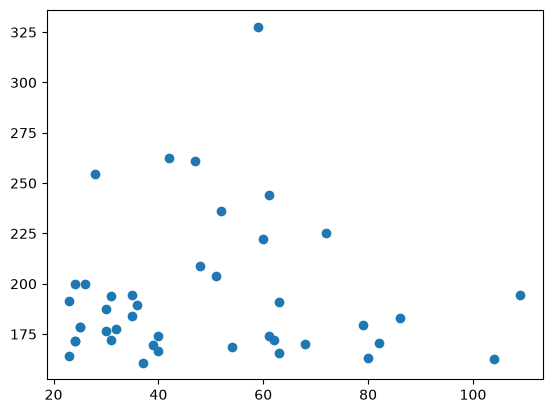

In [351]:
plt.scatter(df_powerhitters["runs"],df_powerhitters["SR"])

In [352]:
df_powerhitters=df_powerhitters[df_powerhitters["balls"]/(df_powerhitters["4s"]+df_powerhitters["6s"])<=4]


In [353]:
count =(df_powerhitters["batsmanName"].value_counts()).loc[lambda x:x>=2]
print(count)


batsmanName
Suryakumar Yadav    3
Finn Allen          2
Quinton de Kock†    2
Glenn Maxwell       2
Name: count, dtype: int64


In [354]:
df_powerhitters = df_powerhitters[df_powerhitters["batsmanName"].isin(count.index)]
df_powerhitters.head()


,match,teamInnings,battingPos,batsmanName,runs,balls,4s,6s,SR,out/not out,match_id
202,New Zealand Vs Australia,New Zealand,1,Finn Allen,42,16,5,3,262.50,out,T20I # 1839
294,Zimbabwe Vs South Africa,South Africa,1,Quinton de Kock†,47,18,8,1,261.11,not out,T20I # 1844
307,Sri Lanka Vs Australia,Australia,4,Glenn Maxwell,23,12,2,2,191.66,out,T20I # 1845
328,South Africa Vs Bangladesh,South Africa,2,Quinton de Kock†,63,38,7,3,165.78,out,T20I # 1847
348,India Vs Netherlands,India,4,Suryakumar Yadav,51,25,7,1,204.00,not out,T20I # 1848


Above batsman are powerhitters of tournament 
plotting them on the graph

In [355]:
df_powerhitters.info

<bound method DataFrame.info of                           match   teamInnings  battingPos       batsmanName  \
202    New Zealand Vs Australia   New Zealand           1        Finn Allen   
294    Zimbabwe Vs South Africa  South Africa           1  Quinton de Kock†   
307      Sri Lanka Vs Australia     Australia           4     Glenn Maxwell   
328  South Africa Vs Bangladesh  South Africa           2  Quinton de Kock†   
348        India Vs Netherlands         India           4  Suryakumar Yadav   
522         India Vs Bangladesh         India           4  Suryakumar Yadav   
556      New Zealand Vs Ireland   New Zealand           1        Finn Allen   
580    Australia Vs Afghanistan     Australia           6     Glenn Maxwell   
647           India Vs Zimbabwe         India           4  Suryakumar Yadav   

     runs  balls  4s  6s      SR out/not out     match_id  
202    42     16   5   3  262.50         out  T20I # 1839  
294    47     18   8   1  261.11     not out  T20I # 1844

In [356]:
total_runs= df_powerhitters.groupby("batsmanName")["runs"].sum().reset_index()
average_strike_rate=df_powerhitters.groupby("batsmanName")["SR"].mean().reset_index()
print(total_runs)
print(average_strike_rate)

        batsmanName  runs
0        Finn Allen    74
1     Glenn Maxwell    77
2  Quinton de Kock†   110
3  Suryakumar Yadav   142
        batsmanName          SR
0        Finn Allen  220.135000
1     Glenn Maxwell  180.205000
2  Quinton de Kock†  213.445000
3  Suryakumar Yadav  211.833333


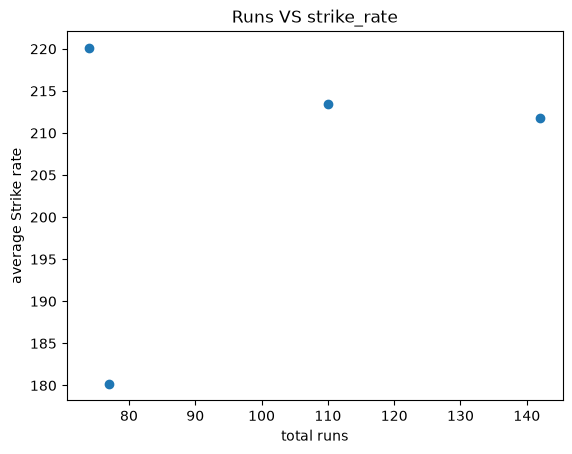

In [357]:
plt.scatter(total_runs["runs"],average_strike_rate["SR"])
plt.xlabel("total runs")
plt.ylabel("average Strike rate")
plt.title("Runs VS strike_rate")
plt.show()

Compare these batsmans performance with other batsmans on the basis of strike rate and runs

using graphs

In [358]:
df_all_batsman=df_batting
df_all_batsman.drop(df_powerhitters.index,inplace=True)
df_all_batsman["runs"]=pd.to_numeric(df_all_batsman["runs"],errors="coerce")
df_all_batsman["SR"]=pd.to_numeric(df_all_batsman["SR"],errors="coerce")
all_batsman_total_runs=df_all_batsman.groupby("batsmanName")["runs"].sum().reset_index()
all_batsman_average_strikerate=df_all_batsman.groupby("batsmanName")["SR"].mean().reset_index()
print(all_batsman_total_runs)
print(all_batsman_average_strikerate)

          batsmanName  runs
0      Aaron Finch(c)   107
1    Aayan Afzal Khan    24
2          Adam Zampa     1
3        Afif Hossain    95
4       Aiden Markram    99
..                ...   ...
195  Wessly Madhevere   106
196         Yasir Ali     5
197       Zahoor Khan     1
198       Zane Green†     2
199       Zawar Farid     2

[200 rows x 2 columns]
          batsmanName          SR
0      Aaron Finch(c)  111.720000
1    Aayan Afzal Khan   80.945000
2          Adam Zampa   50.000000
3        Afif Hossain   98.674000
4       Aiden Markram  122.832500
..                ...         ...
195  Wessly Madhevere   92.051250
196         Yasir Ali   64.443333
197       Zahoor Khan  100.000000
198       Zane Green†   66.660000
199       Zawar Farid   50.000000

[200 rows x 2 columns]


Text(0.5, 1.0, 'Batsman comparison')

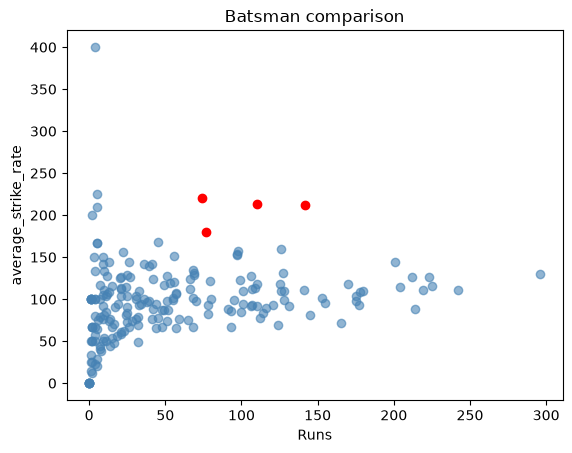

In [364]:
plt.scatter(all_batsman_total_runs["runs"],all_batsman_average_strikerate["SR"],color="steelblue",alpha=0.6,label="Average batsman")
plt.scatter(total_runs["runs"],average_strike_rate["SR"],color="red",label="powerhitters")
plt.xlabel("Runs")
plt.ylabel("average_strike_rate")
plt.title("Batsman comparison")